# COVID Symptoms Causal Analysis Final Project

**Project Title:** COVID-19 Prediction AI System Using Causal Symptom Analysis and Machine Learning  

**Course:** HI 823 - DL1, Professor Hafeez    
**Semester:** Spring 2026  
**Student:** Diana Portillo 

This notebook develops a COVID-19 diagnostic AI system using the COVIDCARE Phase II dataset and DEMI causal analysis. The goal is to predict PCR-confirmed COVID-19 positivity using symptoms, demographics, vaccination status, exposure information, and at-home test results.

In [1]:
# Step 1: Import libraries and load data

import pandas as pd
import numpy as np
import os
import itertools
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    log_loss,
    f1_score
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif

# Set project folder
folder_path = r"C:\Diana\HAP823\Final"

# Load files
patient_data = pd.read_csv(folder_path + r"\COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03.csv")
knowledgebase = pd.read_csv(folder_path + r"\COVIDCARE_DEMI_knowledgebase_v4.csv")

# Clean column names
patient_data.columns = [c.strip() for c in patient_data.columns]
knowledgebase.columns = [c.strip() for c in knowledgebase.columns]

print("Patient data shape:", patient_data.shape)
print("Knowledgebase shape:", knowledgebase.shape)

Patient data shape: (822, 472)
Knowledgebase shape: (70983, 11)


In [2]:
# Step 2: Create output folders

os.makedirs(folder_path + r"\Figures", exist_ok=True)
os.makedirs(folder_path + r"\Outputs", exist_ok=True)
os.makedirs(folder_path + r"\Final_Submission", exist_ok=True)

print("Folders are ready.")

Folders are ready.


## 1. Prepare Analytic Dataset

The primary outcome variable is PCR Test Positive. Patients with missing PCR results are excluded because supervised models require a known outcome.

In [3]:
# Step 3: Check outcome variable

TARGET = "PCR Test Positive"

print("PCR Test Positive counts:")
print(patient_data[TARGET].value_counts(dropna=False))

print("\nPCR Test Positive percentages:")
print(patient_data[TARGET].value_counts(normalize=True, dropna=False) * 100)

PCR Test Positive counts:
PCR Test Positive
0.0    501
NaN    263
1.0     58
Name: count, dtype: int64

PCR Test Positive percentages:
PCR Test Positive
0.0    60.948905
NaN    31.995134
1.0     7.055961
Name: proportion, dtype: float64


In [4]:
# Step 4: Create analytic dataset with known PCR results

model_data = patient_data.copy()

model_data[TARGET] = pd.to_numeric(model_data[TARGET], errors="coerce")
model_data = model_data.dropna(subset=[TARGET])
model_data[TARGET] = model_data[TARGET].astype(int)

print("Original dataset shape:", patient_data.shape)
print("Analytic dataset shape:", model_data.shape)

print("\nPCR outcome distribution:")
print(model_data[TARGET].value_counts())

Original dataset shape: (822, 472)
Analytic dataset shape: (559, 472)

PCR outcome distribution:
PCR Test Positive
0    501
1     58
Name: count, dtype: int64


## 2. Remove Leakage Variables and Prepare Predictors

To prevent data leakage, variables directly related to PCR results, dates, internal identifiers, and cohort assignment are removed from the predictor set. The remaining variables are converted into model-ready numeric predictors using dummy coding.

In [5]:
# Step 5: Create full predictor matrix and remove leakage variables

X_full = pd.get_dummies(model_data.drop(columns=[TARGET]), drop_first=True)

# Remove leakage variables
leakage_keywords = ["pcr", "result", "date", "deid", "internal", "cohort"]

def is_leakage(col):
    c = col.lower()
    return any(k in c for k in leakage_keywords)

X_full = X_full[[c for c in X_full.columns if not is_leakage(c)]]

y = model_data[TARGET]

print("X_full shape after leakage removal:", X_full.shape)
print("y shape:", y.shape)

X_full shape after leakage removal: (559, 998)
y shape: (559,)


In [6]:
# Step 6: Split data into training and testing sets

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Training data shape:", X_train_base.shape)
print("Testing data shape:", X_test_base.shape)

print("\nTraining target counts:")
print(y_train.value_counts())

print("\nTesting target counts:")
print(y_test.value_counts())

Training data shape: (419, 998)
Testing data shape: (140, 998)

Training target counts:
PCR Test Positive
0    376
1     43
Name: count, dtype: int64

Testing target counts:
PCR Test Positive
0    125
1     15
Name: count, dtype: int64


## 3. Mutual Information Feature Selection

Mutual information was used to select the top predictors from the full feature set. This reduces the number of variables before creating interaction terms.

In [7]:
# Step 7: Select top predictors using mutual information

mi = mutual_info_classif(X_train_base.fillna(0), y_train, random_state=42)

mi_df = pd.DataFrame({
    "feature": X_train_base.columns,
    "mi": mi
}).sort_values("mi", ascending=False)

selected_features = mi_df.head(40)["feature"].tolist()

X_train_selected = X_train_base[selected_features]
X_test_selected = X_test_base[selected_features]

print("Selected feature count:", len(selected_features))

mi_df.head(15)

Selected feature count: 40


,feature,mi
108,30132-covid_tested30,0.133659
13,32730-howreceive,0.092653
191,30158-Symtpom_Neuro-7,0.080194
166,30153-Symptoms-6,0.079817
3,29792-consent_covid+,0.075822
277,30766-pinkblue_confirm,0.070477
168,30154-Symptoms_Resp-1,0.067208
393,32316-have_allitems_2,0.064059
276,32016-time_picker,0.057532
170,30154-Symptoms_Resp-3,0.057392


## 4. Create Interaction Terms

Interaction terms were created to capture combinations of symptoms and testing variables. This helps the model represent situations where multiple symptoms together may be more informative than one symptom alone.

In [8]:
# Step 8: Create interaction terms

def assign_tier(col):
    c = str(col).lower()
    
    if c == "pcr test positive":
        return 4
    if any(k in c for k in ["pink", "blue", "athome", "testkit", "confirm"]):
        return 3
    if any(k in c for k in ["vaccine", "vacc"]):
        return 1
    if any(k in c for k in ["age", "gender", "race", "ethnicity", "birthsex"]):
        return 0
    
    return 2

symptom_vars = [c for c in selected_features if assign_tier(c) in [2, 3]]

pair_base = symptom_vars[:15]
triple_base = symptom_vars[:6]

def create_interactions(X):
    interaction_data = {}
    
    for a, b in itertools.combinations(pair_base, 2):
        interaction_data[f"{a}__{b}"] = X[a] * X[b]
        
    for a, b, c in itertools.combinations(triple_base, 3):
        interaction_data[f"{a}__{b}__{c}"] = X[a] * X[b] * X[c]
    
    interaction_df = pd.DataFrame(interaction_data, index=X.index)
    
    X_combined = pd.concat([X.copy(), interaction_df], axis=1)
    
    return X_combined

X_train = create_interactions(X_train_selected)
X_test = create_interactions(X_test_selected)

print("Training data shape after interactions:", X_train.shape)
print("Testing data shape after interactions:", X_test.shape)

Training data shape after interactions: (419, 165)
Testing data shape after interactions: (140, 165)


## 5. Train Logistic Regression, LASSO, and Gradient Boosting Models

Three models were trained and compared: logistic regression as the baseline model, LASSO logistic regression for feature selection and interpretability, and gradient boosting as a nonlinear machine learning model.

In [9]:
# Step 9: Define models and evaluation metrics

prep_scaled = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("sc", StandardScaler(with_mean=False))
])

prep_unscaled = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent"))
])

models = {
    "Logistic Regression": Pipeline([
        ("prep", prep_scaled),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
    ]),
    
    "LASSO": Pipeline([
        ("prep", prep_scaled),
        ("model", LogisticRegressionCV(
            penalty="l1",
            solver="saga",
            cv=5,
            max_iter=5000,
            scoring="roc_auc",
            class_weight="balanced"
        ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("prep", prep_unscaled),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

def mcfadden_r2(y_true, p_pred):
    p_pred = np.clip(p_pred, 1e-8, 1 - 1e-8)
    ll_model = -log_loss(y_true, p_pred, normalize=False)
    ll_null = -log_loss(y_true, np.repeat(np.mean(y_true), len(y_true)), normalize=False)
    return 1 - ll_model / ll_null

In [10]:
# Step 10: Train and evaluate all models

results = []
fitted_models = {}
model_probabilities = {}
model_predictions = {}

for name, model in models.items():
    print("Training:", name)
    
    model.fit(X_train, y_train)
    fitted_models[name] = model
    
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob > 0.5).astype(int)
    
    model_probabilities[name] = prob
    model_predictions[name] = pred
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "AUC": roc_auc_score(y_test, prob),
        "F1": f1_score(y_test, pred),
        "McFadden_R2": mcfadden_r2(y_test, prob)
    })

results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)

results_df

Training: Logistic Regression
Training: LASSO
Training: Gradient Boosting


,Model,Accuracy,AUC,F1,McFadden_R2
1,LASSO,0.928571,0.917067,0.705882,0.154171
0,Logistic Regression,0.935714,0.909067,0.689655,-0.234856
2,Gradient Boosting,0.928571,0.909067,0.642857,0.156162


In [11]:
# Step 11: Save model comparison results

results_df.to_csv(folder_path + r"\Outputs\model_comparison_all_models.csv", index=False)

print("Model comparison saved.")

Model comparison saved.


In [12]:
# Step 12: Display classification report for the best model by AUC

best_model_name = results_df.iloc[0]["Model"]

print("Best model based on AUC:", best_model_name)

best_pred = model_predictions[best_model_name]
best_prob = model_probabilities[best_model_name]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Best model based on AUC: LASSO

Confusion Matrix:
[[118   7]
 [  3  12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       125
           1       0.63      0.80      0.71        15

    accuracy                           0.93       140
   macro avg       0.80      0.87      0.83       140
weighted avg       0.94      0.93      0.93       140



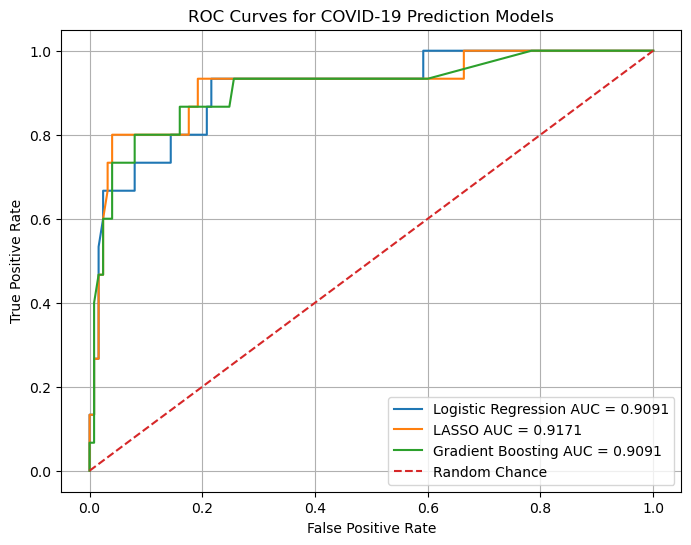

In [13]:
# Step 13: ROC curves for all models

plt.figure(figsize=(8, 6))

for name, prob in model_probabilities.items():
    fpr, tpr, thresholds = roc_curve(y_test, prob)
    auc_value = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} AUC = {auc_value:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for COVID-19 Prediction Models")
plt.legend()
plt.grid(True)
plt.show()

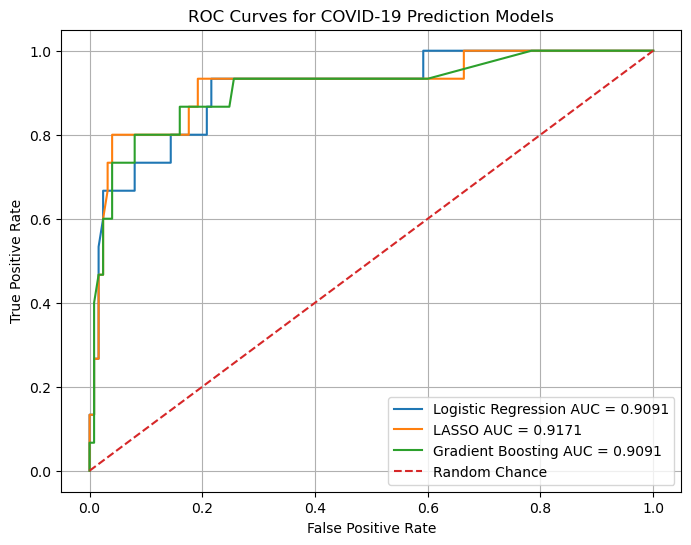

ROC curve saved.


In [14]:
# Step 14: Save ROC curve

plt.figure(figsize=(8, 6))

for name, prob in model_probabilities.items():
    fpr, tpr, thresholds = roc_curve(y_test, prob)
    auc_value = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} AUC = {auc_value:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for COVID-19 Prediction Models")
plt.legend()
plt.grid(True)
plt.savefig(folder_path + r"\Figures\roc_curves_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

print("ROC curve saved.")

## 6. Direct Predictors from LASSO

The LASSO model was used to identify predictors with nonzero coefficients. These predictors were treated as candidate direct predictors of PCR positivity.

In [15]:
# Step 15: Extract LASSO direct predictors

lasso_fitted = fitted_models["LASSO"].named_steps["model"]

lasso_coef = pd.Series(lasso_fitted.coef_[0], index=X_train.columns)

direct_predictors = lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False)

direct_predictors_df = direct_predictors.reset_index()
direct_predictors_df.columns = ["Predictor", "Coefficient"]

direct_predictors_df["Abs_Coefficient"] = direct_predictors_df["Coefficient"].abs()

direct_predictors_df.head(20)

,Predictor,Coefficient,Abs_Coefficient
0,32730-howreceive,0.710635,0.710635
1,30766-pinkblue_confirm__30154-Symptoms_Resp-3,0.619721,0.619721
2,30158-Symtpom_Neuro-7__30769-blue_nopink_confirm,0.381436,0.381436
3,32730-howreceive__29792-consent_covid+,-0.290390,0.290390
4,29792-consent_covid+,-0.220610,0.220610
5,32137-vaccine_avail,0.194612,0.194612
6,32730-howreceive__30141-covid_tst_symptoms-6,0.129770,0.129770
7,30158-Symtpom_Neuro-7__30155-Symptom_Resp_other,0.114861,0.114861
8,30132-covid_tested30__30766-pinkblue_confirm,0.101647,0.101647
9,30158-Symtpom_Neuro-7,0.091348,0.091348


In [16]:
# Step 16: Save LASSO direct predictors

direct_predictors_df.to_csv(folder_path + r"\Outputs\lasso_direct_predictors_combined.csv", index=False)

print("LASSO direct predictors saved.")

LASSO direct predictors saved.


## 7. Gradient Boosting Feature Importance

Feature importance from the gradient boosting model was used to identify the predictors that contributed most strongly to prediction.

In [17]:
# Step 17: Gradient Boosting feature importance

gb_fitted = fitted_models["Gradient Boosting"].named_steps["model"]

gb_importance = pd.DataFrame({
    "Predictor": X_train.columns,
    "Importance": gb_fitted.feature_importances_
}).sort_values(by="Importance", ascending=False)

gb_importance.head(15)

,Predictor,Importance
1,32730-howreceive,0.372753
103,30766-pinkblue_confirm__30154-Symptoms_Resp-3,0.300431
72,30158-Symtpom_Neuro-7__32016-time_picker,0.074468
75,30158-Symtpom_Neuro-7__30769-blue_nopink_confirm,0.049547
21,32137-vaccine_avail,0.029064
60,32730-howreceive__32016-time_picker,0.020771
126,32016-time_picker__30769-blue_nopink_confirm,0.019181
8,32016-time_picker,0.018739
41,30132-covid_tested30__30158-Symtpom_Neuro-7,0.016072
106,30766-pinkblue_confirm__30138-COVID_Why-1,0.012046


In [18]:
# Step 18: Save Gradient Boosting feature importance

gb_importance.to_csv(folder_path + r"\Outputs\gradient_boosting_feature_importance_combined.csv", index=False)

print("Gradient Boosting feature importance saved.")

Gradient Boosting feature importance saved.


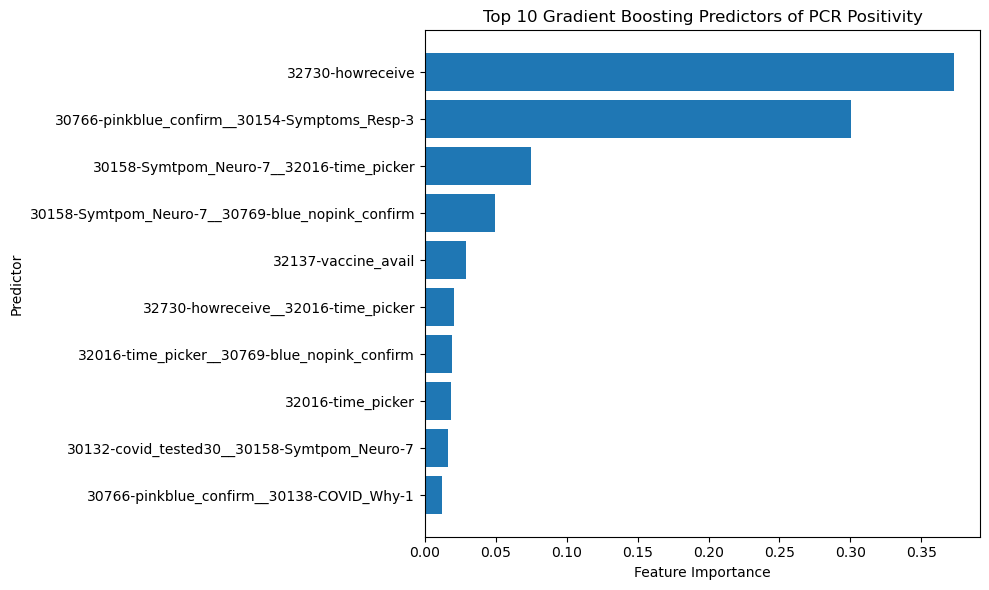

In [19]:
# Step 19: Plot top 10 Gradient Boosting predictors

top10_gb = gb_importance.head(10).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top10_gb["Predictor"], top10_gb["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Top 10 Gradient Boosting Predictors of PCR Positivity")
plt.tight_layout()
plt.show()

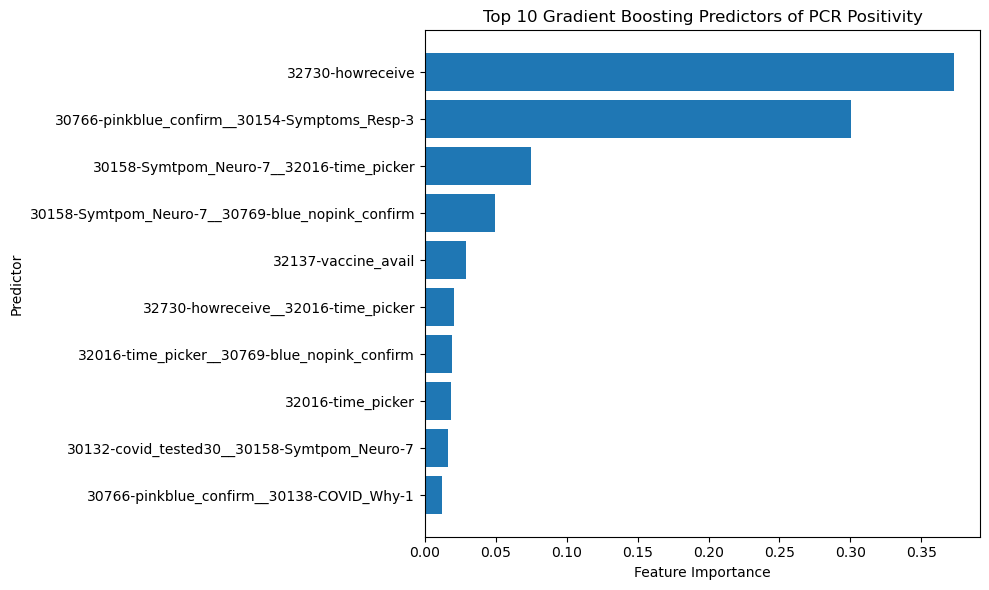

Gradient Boosting top 10 feature chart saved.


In [20]:
# Step 20: Save top 10 feature importance chart

plt.figure(figsize=(10, 6))
plt.barh(top10_gb["Predictor"], top10_gb["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Top 10 Gradient Boosting Predictors of PCR Positivity")
plt.tight_layout()
plt.savefig(folder_path + r"\Figures\gradient_boosting_top10_features_combined.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gradient Boosting top 10 feature chart saved.")

## 8. DEMI Total Effect Analysis

The DEMI total effect analysis uses 2 by 2 tables to estimate the association between each predictor and PCR positivity. The odds ratio is used as the total effect measure.

In [21]:
# Step 21: DEMI total effect analysis on selected original features

def calculate_total_effect(df, predictor, outcome):
    temp = df[[predictor, outcome]].copy()
    temp[predictor] = pd.to_numeric(temp[predictor], errors="coerce")
    temp[outcome] = pd.to_numeric(temp[outcome], errors="coerce")
    temp = temp.dropna()
    
    temp[predictor] = np.where(temp[predictor] > 0, 1, 0)
    temp[outcome] = temp[outcome].astype(int)
    
    a = len(temp[(temp[predictor] == 1) & (temp[outcome] == 1)])
    b = len(temp[(temp[predictor] == 1) & (temp[outcome] == 0)])
    c = len(temp[(temp[predictor] == 0) & (temp[outcome] == 1)])
    d = len(temp[(temp[predictor] == 0) & (temp[outcome] == 0)])
    
    odds_ratio = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
    log_or = np.log(odds_ratio)
    
    return pd.Series({
        "Predictor": predictor,
        "a": a,
        "b": b,
        "c": c,
        "d": d,
        "Odds_Ratio": odds_ratio,
        "Log_OR_Total_Effect": log_or
    })

# Use only selected features that exist as original columns in model_data
demi_predictors = [f for f in selected_features if f in model_data.columns]

print("Number of selected original predictors for DEMI:", len(demi_predictors))

total_effects = pd.DataFrame([
    calculate_total_effect(model_data, predictor, TARGET)
    for predictor in demi_predictors
])

total_effects = total_effects.sort_values(by="Odds_Ratio", ascending=False)

total_effects.head(15)

Number of selected original predictors for DEMI: 32


,Predictor,a,b,c,d,Odds_Ratio,Log_OR_Total_Effect
14,36104-Post_vaccinefactors-12,7,2,31,439,41.857143,3.734262
22,30141-covid_tst_symptoms-23,13,4,39,470,35.734177,3.576108
2,30158-Symtpom_Neuro-7,24,11,28,463,34.647597,3.545228
29,32356-pinkblue_confirm_2,13,6,27,458,34.627972,3.544662
18,30158-Symtpom_Neuro-8,20,8,32,466,34.618100,3.544377
5,30766-pinkblue_confirm,23,11,27,459,34.144664,3.530606
11,36096-Post_covidvaccine,36,166,2,275,24.157958,3.184614
16,30141-covid_tst_symptoms-5,21,13,31,461,23.332745,3.149858
3,30153-Symptoms-6,25,21,27,453,19.558985,2.973435
10,30141-covid_tst_symptoms-6,31,36,21,438,17.601465,2.867982


In [22]:
# Step 22: Save DEMI total effects

total_effects.to_csv(folder_path + r"\Outputs\demi_total_effects_combined.csv", index=False)

print("DEMI total effects saved.")

DEMI total effects saved.


In [23]:
# Step 23: Top 10 DEMI total effects

top10_total_effects = total_effects.head(10)

top10_total_effects

,Predictor,a,b,c,d,Odds_Ratio,Log_OR_Total_Effect
14,36104-Post_vaccinefactors-12,7,2,31,439,41.857143,3.734262
22,30141-covid_tst_symptoms-23,13,4,39,470,35.734177,3.576108
2,30158-Symtpom_Neuro-7,24,11,28,463,34.647597,3.545228
29,32356-pinkblue_confirm_2,13,6,27,458,34.627972,3.544662
18,30158-Symtpom_Neuro-8,20,8,32,466,34.618100,3.544377
5,30766-pinkblue_confirm,23,11,27,459,34.144664,3.530606
11,36096-Post_covidvaccine,36,166,2,275,24.157958,3.184614
16,30141-covid_tst_symptoms-5,21,13,31,461,23.332745,3.149858
3,30153-Symptoms-6,25,21,27,453,19.558985,2.973435
10,30141-covid_tst_symptoms-6,31,36,21,438,17.601465,2.867982


In [24]:
# Step 24: Save top 10 DEMI total effects

top10_total_effects.to_csv(folder_path + r"\Outputs\demi_top10_total_effects_combined.csv", index=False)

print("Top 10 DEMI total effects saved.")

Top 10 DEMI total effects saved.


## 9. DEMI Diagnostic Network

A DEMI-based diagnostic network was created using the top 10 total effect predictors. Each predictor points to the outcome node, PCR Positive.

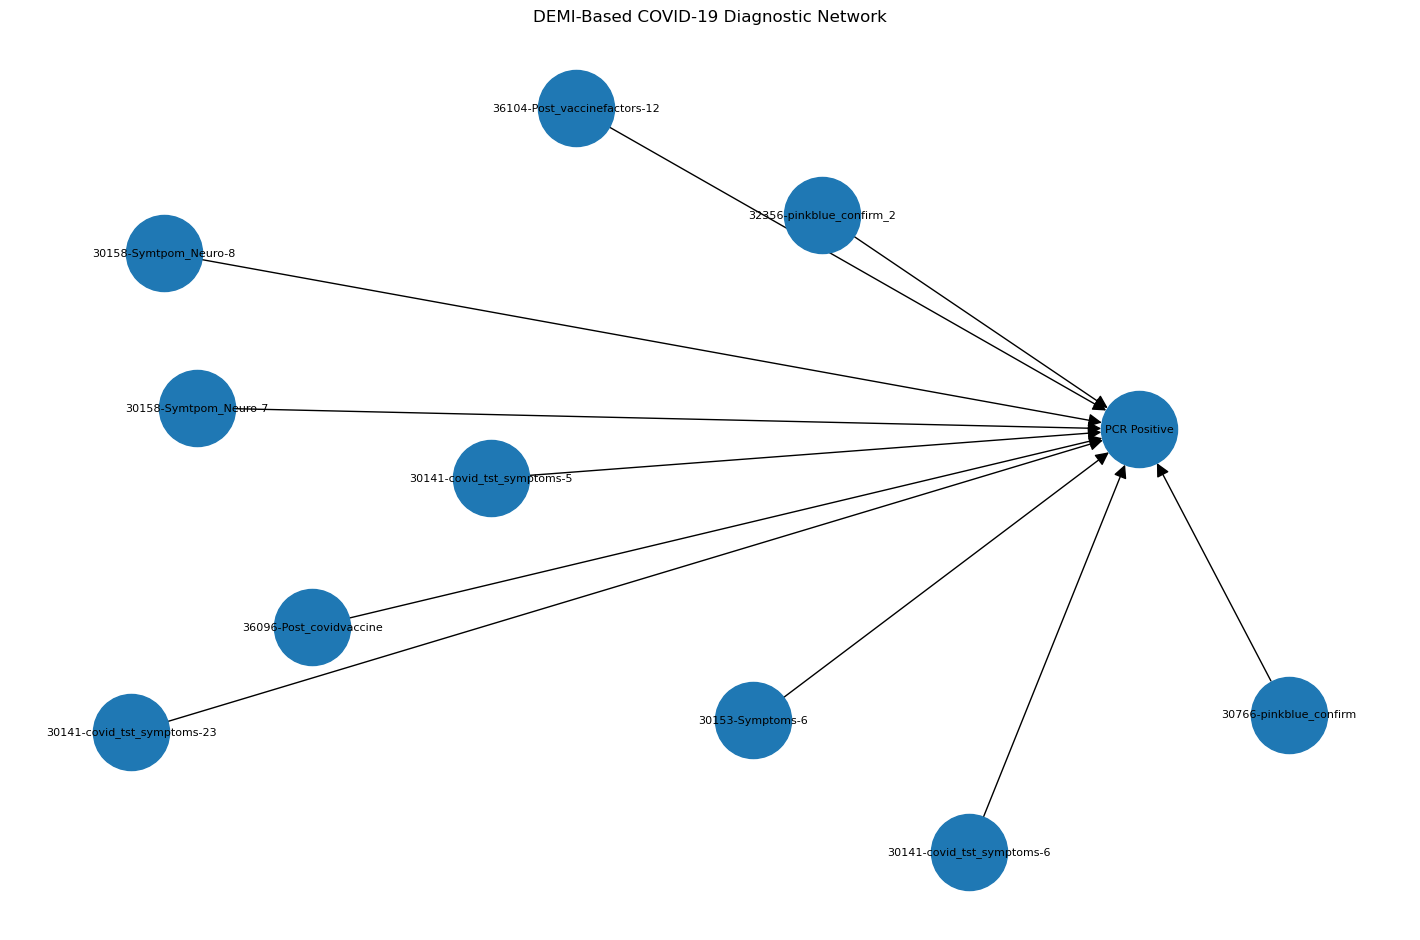

In [25]:
# Step 25: Create DEMI diagnostic network

G = nx.DiGraph()

outcome_node = "PCR Positive"

for _, row in top10_total_effects.iterrows():
    G.add_edge(row["Predictor"], outcome_node)

plt.figure(figsize=(14, 9))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=8,
    arrows=True,
    arrowsize=20
)

plt.title("DEMI-Based COVID-19 Diagnostic Network")
plt.show()

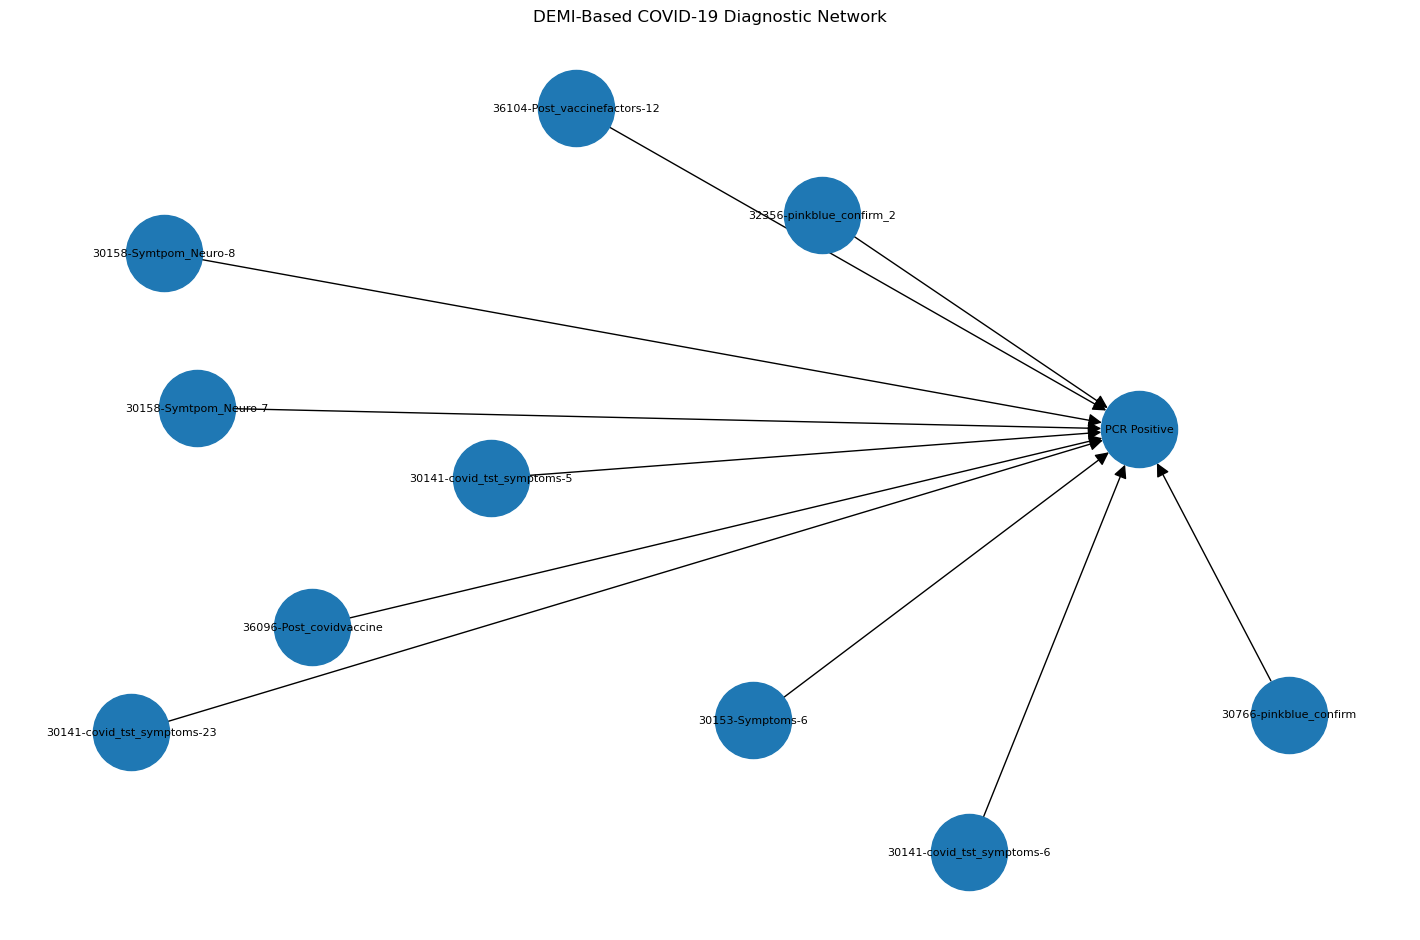

DEMI diagnostic network saved.


In [26]:
# Step 26: Save DEMI diagnostic network

plt.figure(figsize=(14, 9))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=8,
    arrows=True,
    arrowsize=20
)

plt.title("DEMI-Based COVID-19 Diagnostic Network")
plt.savefig(folder_path + r"\Figures\demi_covid_diagnostic_network_combined.png", dpi=300, bbox_inches="tight")
plt.show()

print("DEMI diagnostic network saved.")

## 10. Final COVID Prediction Function

The final prediction function accepts patient-level inputs and returns an estimated probability of PCR-positive COVID-19 using the best-performing model.

In [27]:
# Step 27: Final COVID prediction function

best_model = fitted_models[best_model_name]

def predict_case(input_dict):
    """
    Predicts the probability of PCR-positive COVID-19.
    The input should include patient-level variables from the selected feature set.
    Missing variables are filled with 0.
    """
    case_base = pd.DataFrame(0, index=[0], columns=selected_features)
    
    for key, value in input_dict.items():
        if key in case_base.columns:
            case_base[key] = value
    
    case_full = create_interactions(case_base)
    
    # Make sure columns match training data
    case_full = case_full.reindex(columns=X_train.columns, fill_value=0)
    
    probability = best_model.predict_proba(case_full)[0, 1]
    
    return probability

In [28]:
# Step 28: Example patient scenario

example_patient = {
    "30132-covid_tested30": 1,
    "30153-Symptoms-6": 1,
    "30154-Symptoms_Resp-3": 1,
    "30766-pinkblue_confirm": 1
}

covid_probability = predict_case(example_patient)

print("Best model used:", best_model_name)
print("Predicted probability of PCR-positive COVID-19:", round(covid_probability, 4))
print("Predicted percentage:", round(covid_probability * 100, 2), "%")

Best model used: LASSO
Predicted probability of PCR-positive COVID-19: 0.5947
Predicted percentage: 59.47 %


In [29]:
# Step 29: Final summary results

summary_results = pd.DataFrame({
    "Result": [
        "Original dataset size",
        "Final analytic sample",
        "PCR-negative patients",
        "PCR-positive patients",
        "Best model by AUC",
        "Best model AUC",
        "Best model accuracy",
        "Best model F1",
        "Best model McFadden R2",
        "Number of selected features",
        "Number of features after interactions",
        "Number of LASSO direct predictors",
        "Top DEMI total effect predictor"
    ],
    "Value": [
        str(patient_data.shape),
        str(model_data.shape),
        int((model_data[TARGET] == 0).sum()),
        int((model_data[TARGET] == 1).sum()),
        best_model_name,
        round(results_df.iloc[0]["AUC"], 4),
        round(results_df.iloc[0]["Accuracy"], 4),
        round(results_df.iloc[0]["F1"], 4),
        round(results_df.iloc[0]["McFadden_R2"], 4),
        len(selected_features),
        X_train.shape[1],
        len(direct_predictors_df),
        top10_total_effects.iloc[0]["Predictor"] if len(top10_total_effects) > 0 else "Not available"
    ]
})

summary_results

,Result,Value
0,Original dataset size,"(822, 472)"
1,Final analytic sample,"(559, 472)"
2,PCR-negative patients,501
3,PCR-positive patients,58
4,Best model by AUC,LASSO
5,Best model AUC,0.9171
6,Best model accuracy,0.9286
7,Best model F1,0.7059
8,Best model McFadden R2,0.1542
9,Number of selected features,40


In [30]:
# Step 30: Save final summary results

summary_results.to_csv(folder_path + r"\Outputs\final_project_summary_results_combined.csv", index=False)

print("Final project summary results saved.")

Final project summary results saved.


## 11. Conclusion

This project developed a COVID-19 prediction AI system using the COVIDCARE dataset, machine learning, and DEMI causal analysis. Records with missing PCR results were excluded, resulting in a final analytic sample of 559 patients. Leakage variables were removed, mutual information was used for feature selection, and interaction terms were created to capture symptom combinations. Logistic regression, LASSO, and gradient boosting were compared using accuracy, AUC, F1-score, and McFadden pseudo R-square. DEMI total effect analysis was used to identify predictors with strong associations with PCR positivity, and a diagnostic network was created to visualize the strongest predictors. The final prediction function demonstrated how patient-level inputs can be used to estimate the probability of PCR-positive COVID-19.